# Bateria de Testes 1 - TradeOff

Para Coletarmos as metricas dessa bateria de testes temos que rodar esse comando:

In [ ]:
!python3 automation_controller_tradeoff.py --iterations 30 --duration 180 --profile wan-fiber

Apos rodar esse comando que vai demorar por volta de 9 hrs de teste, vamos ter os dados na pasta teste_tradeoff com subpastas com os intervalos de 5s a 60s, onde podemos usar para analisar.

## Analise das metricas coletadas

Primeiro vamos carregar os dados, e depois unificar eles num dataframe:

In [2]:
import pandas as pd
import os
import json
import glob
from tqdm import tqdm

base_path = "teste_tradeoff"
intervals = [2, 5, 10, 30, 60]

def unificar_experimento():
    sdn_list = []
    res_list = []
    thr_list = []

    for sec in intervals:
        folder = os.path.join(base_path, f"interval_{sec}s")
        print(f"\nProcessando intervalo de {sec}s...")
        
        # --- 1. Processar SDN Metrics (Latência/Hibridização) ---
        sdn_file = os.path.join(folder, "sdn_metrics.csv")
        if os.path.exists(sdn_file):
            df = pd.read_csv(sdn_file)
            df['interval'] = sec  # Adiciona a coluna que identifica o teste
            sdn_list.append(df)
            print(f"  ✓ SDN metrics: {len(df)} linhas")

        # --- 2. Processar Resource Metrics (CPU/RAM) ---
        res_file = os.path.join(folder, "resource_metrics.csv")
        if os.path.exists(res_file):
            df = pd.read_csv(res_file)
            df['interval'] = sec
            res_list.append(df)
            print(f"  ✓ Resource metrics: {len(df)} linhas")

        # --- 3. Processar JSONs do IPerf (Vazão Real) ---
        json_files = glob.glob(os.path.join(folder, "throughput_iter_*.json"))
        print(f"  Processando {len(json_files)} arquivos JSON...")
        for jf in tqdm(json_files, desc=f"  Intervalo {sec}s"):
            try:
                with open(jf, 'r') as f:
                    data = json.load(f)
                    # Extrai a vazão média em Mbps (bits_per_second / 1e6)
                    bps = data['end']['sum_received']['bits_per_second']
                    thr_list.append({'interval': sec, 'throughput_mbps': bps / 1e6})
            except Exception as e:
                print(f"    ⚠ Erro ao processar {jf}: {e}")

    # Criar os DataFrames Mestres
    print("\nCriando DataFrames mestres...")
    master_sdn = pd.concat(sdn_list, ignore_index=True) if sdn_list else pd.DataFrame()
    master_res = pd.concat(res_list, ignore_index=True) if res_list else pd.DataFrame()
    master_thr = pd.DataFrame(thr_list)
    
    print(f"\n✅ Concluído!")
    print(f"  - SDN metrics: {len(master_sdn)} linhas")
    print(f"  - Resource metrics: {len(master_res)} linhas")
    print(f"  - Throughput: {len(master_thr)} medições")

    return master_sdn, master_res, master_thr

df_sdn, df_res, df_thr = unificar_experimento()


Processando intervalo de 2s...
  ✓ SDN metrics: 5642 linhas
  ✓ Resource metrics: 9125 linhas
  Processando 30 arquivos JSON...


  Intervalo 2s: 100%|██████████| 30/30 [00:00<00:00, 1004.10it/s]



Processando intervalo de 5s...
  ✓ SDN metrics: 5612 linhas
  ✓ Resource metrics: 9110 linhas
  Processando 30 arquivos JSON...


  Intervalo 5s: 100%|██████████| 30/30 [00:00<00:00, 966.52it/s]



Processando intervalo de 10s...
  ✓ SDN metrics: 5630 linhas
  ✓ Resource metrics: 9110 linhas
  Processando 30 arquivos JSON...


...

  Intervalo 30s: 100%|██████████| 30/30 [00:00<00:00, 845.82it/s]


Processando intervalo de 60s...


  ✓ SDN metrics: 5612 linhas
  ✓ Resource metrics: 9115 linhas
  Processando 30 arquivos JSON...


  Intervalo 60s: 100%|██████████| 30/30 [00:00<00:00, 845.65it/s]


Criando DataFrames mestres...

✅ Concluído!
  - SDN metrics: 28126 linhas
  - Resource metrics: 45570 linhas
  - Throughput: 150 medições


Calculamos os dados da janela de exposição

In [3]:
# 1. Calcula a média de vazão por intervalo
avg_thr = df_thr.groupby('interval')['throughput_mbps'].mean().reset_index()

# 2. Mescla essa média com a tabela de SDN
df_final = pd.merge(df_sdn, avg_thr, on='interval')

# 3. Calcula a Janela de Exposição (Volume de dados por chave)
# Fórmula: (Intervalo em segundos * Vazão em Mbps) / 8 para ter em MegaBytes (MB)
df_final['exposure_mb'] = (df_final['interval'] * df_final['throughput_mbps']) / 8

✅ Gráfico 'grafico_tradeoff_final.png' gerado com sucesso!


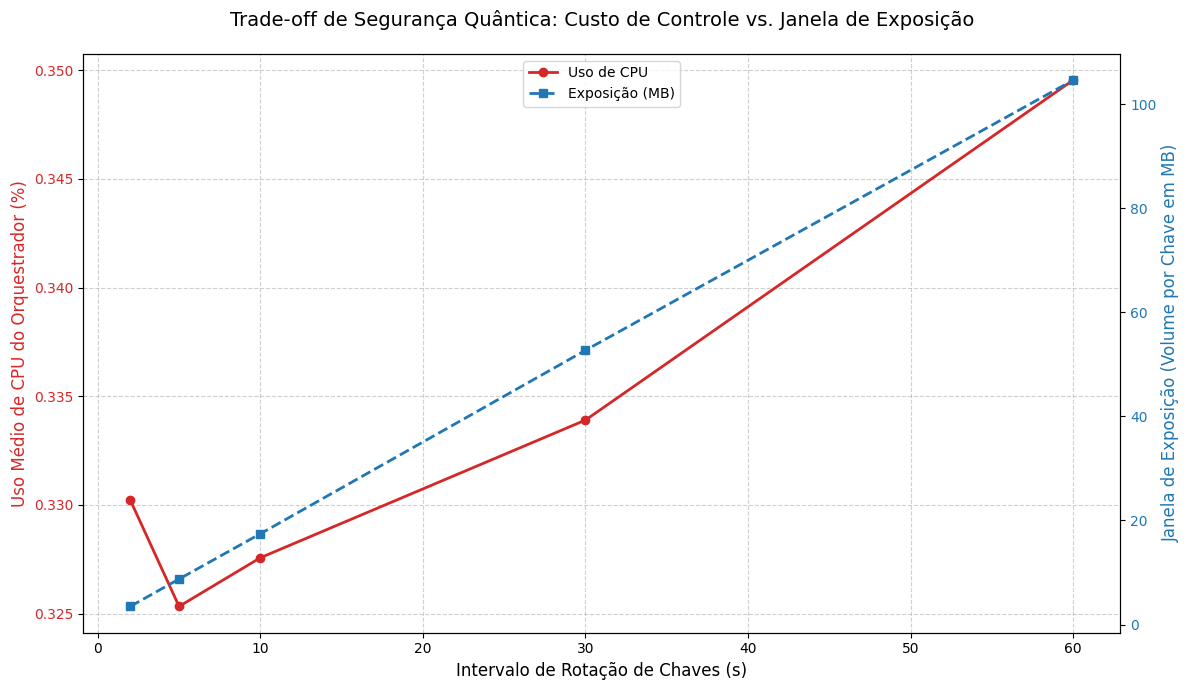

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_tradeoff_analysis(df_res, df_final):
    # 1. Agrupar dados por intervalo para obter as médias
    # Focamos no CPU do orquestrador, que é o coração do plano de controle
    cpu_data = df_res[df_res['container'] == 'orchestrator'].groupby('interval')['cpu_perc'].mean()
    
    # Focamos na média da janela de exposição calculada anteriormente
    exposure_data = df_final.groupby('interval')['exposure_mb'].mean()
    
    # 2. Configurar a figura e o primeiro eixo (CPU)
    fig, ax1 = plt.subplots(figsize=(12, 7))
    
    color_cpu = 'tab:red'
    ax1.set_xlabel('Intervalo de Rotação de Chaves (s)', fontsize=12)
    ax1.set_ylabel('Uso Médio de CPU do Orquestrador (%)', color=color_cpu, fontsize=12)
    ax1.plot(cpu_data.index, cpu_data.values, color=color_cpu, marker='o', linewidth=2, label='Uso de CPU')
    ax1.tick_params(axis='y', labelcolor=color_cpu)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # 3. Criar o segundo eixo compartilhado (Janela de Exposição)
    ax2 = ax1.twinx()
    
    color_exp = 'tab:blue'
    ax2.set_ylabel('Janela de Exposição (Volume por Chave em MB)', color=color_exp, fontsize=12)
    ax2.plot(exposure_data.index, exposure_data.values, color=color_exp, marker='s', linestyle='--', linewidth=2, label='Exposição (MB)')
    ax2.tick_params(axis='y', labelcolor=color_exp)
    
    # 4. Título e Legendas
    plt.title('Trade-off de Segurança Quântica: Custo de Controle vs. Janela de Exposição', fontsize=14, pad=20)
    
    # Unificar as legendas de ambos os eixos
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', frameon=True)
    
    # Salvar o gráfico para o artigo
    plt.tight_layout()
    plt.savefig('grafico_tradeoff_final.png', dpi=300)
    print("✅ Gráfico 'grafico_tradeoff_final.png' gerado com sucesso!")

# Chamar a função
plot_tradeoff_analysis(df_res, df_final)